# MLP-008 — Age median by Title

Воспроизводимый PyTorch MLP-эксперимент. Источник истины — модуль
`ml_project.mlp_experiments.mlp_008_age_by_title`: в нём редактируются признаки, типы заполнения пропусков,
гиперпараметры и архитектура. Этот notebook загружает модуль, проверяет контракт,
выполняет честный внешний CV и сохраняет OOF-результаты.

Рабочий цикл: **одна гипотеза → изменение модуля → Restart Kernel → Run All → вывод**.

Внешний validation fold никогда не участвует в preprocessing, early stopping или
выборе эпохи. Внутри каждого outer train fold создаётся свой inner validation split.


## 1. Что редактировать

Открой `src/ml_project/mlp_experiments/mlp_008_age_by_title.py`.

- `prepare_features(frame)` — только признаки, вычисляемые отдельно для каждой строки.
- `build_fold_transformer()` — обучаемые групповые признаки и статистики train fold.
- `numeric_features` и `categorical_features` — явные роли всех входов.
- `MLPTrainingConfig` — imputation, scaling, batch size, learning rate, epochs.
- `build_network(input_dim)` — любое строение на `nn.Module`, выдающее один логит на строку.

Если новый признак использует статистику нескольких строк — среднее, частоту,
группировку, target encoding — его нельзя заранее считать на всей таблице.
Создавайте его через `build_fold_transformer`: runtime отдельно вызовет `fit`
на train fold и `transform` на validation/test.


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (p / "README.md").is_file() and (p / "src").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import DataCatalog
import ml_project.config as project_config
import ml_project.mlp_experiment as mlp_tools

EXPERIMENT_MODULE = 'ml_project.mlp_experiments.mlp_008_age_by_title'
mlp_tools = importlib.reload(mlp_tools)
experiment_module = mlp_tools.load_mlp_experiment(EXPERIMENT_MODULE)
spec = experiment_module.EXPERIMENT

print("Project:", PROJECT_ROOT)
print("Experiment:", spec.experiment_id, spec.title)
print("Module:", EXPERIMENT_MODULE)
print("Hypothesis:", spec.hypothesis)
print("Controlled change:", spec.change_description)
print("Reference:", spec.parent_mlp_module or spec.sklearn_reference_module or "logistic baseline")
display(pd.Series(vars(spec.training), name="value").to_frame())


Project: D:\Projects\Titanik-ML-project
Experiment: MLP-008 Заполнение Age медианой по Title
Module: ml_project.mlp_experiments.mlp_008_age_by_title
Hypothesis: Если заполнять пропуски Age медианой возраста пассажиров с тем же нормализованным Title внутри train-fold, то MLP точнее учтёт возрастные различия между Mr, Mrs, Miss и Master.
Controlled change: Относительно принятого MLP-002 изменяется только заполнение Age: медиана по Title с fallback на общую медиану train-fold.
Reference: ml_project.mlp_experiments.mlp_002_mlp_8neurons_feng


,value
numeric_imputer,median
categorical_imputer,most_frequent
numeric_scaler,standard
batch_size,32
learning_rate,0.001
weight_decay,0.0
max_epochs,100
patience,12
min_delta,0.0001
inner_validation_fraction,0.15


## 2. Данные и feature contract

`prepare_features` вызывается отдельно для train и inference. Исходные таблицы
должны остаться неизменными, порядок строк, key и target сохраняются.
Заполнение пропусков и one-hot здесь ещё не выполняются — они fit-ятся внутри folds.


In [2]:
catalog = DataCatalog(PROJECT_ROOT, project_config.RAW_DIR, project_config.DATASETS)
catalog.validate()
raw_train = catalog.load(project_config.TRAIN_DATASET)
raw_test = catalog.load(project_config.INFERENCE_DATASET)
train_snapshot = raw_train.copy(deep=True)
test_snapshot = raw_test.copy(deep=True)

prepared = experiment_module.prepare_features(raw_train.copy(deep=True))
prepared_test = experiment_module.prepare_features(raw_test.copy(deep=True))
pd.testing.assert_frame_equal(raw_train, train_snapshot)
pd.testing.assert_frame_equal(raw_test, test_snapshot)
mlp_tools.validate_feature_data(
    prepared, raw_train, target=project_config.TARGET, key=project_config.KEY,
)

if project_config.TARGET in prepared_test.frame:
    raise ValueError("Inference data must not acquire target")
if not prepared_test.frame.index.equals(raw_test.index):
    raise ValueError("prepare_features changed inference row index/order")
if prepared.numeric_features != prepared_test.numeric_features:
    raise ValueError("Train/test numeric feature declarations differ")
if prepared.categorical_features != prepared_test.categorical_features:
    raise ValueError("Train/test categorical feature declarations differ")
missing_test = [
    name for name in prepared.features
    if name not in prepared_test.frame and name not in prepared.fold_generated_features
]
if missing_test:
    raise KeyError(f"Inference is missing features: {missing_test}")

feature_report = pd.DataFrame({
    "role": ["numeric"] * len(prepared.numeric_features)
            + ["categorical"] * len(prepared.categorical_features),
    "feature": list(prepared.features),
}).set_index("feature")
train_feature_view = prepared.frame.reindex(columns=list(prepared.features))
test_feature_view = prepared_test.frame.reindex(columns=list(prepared.features))
feature_report["dtype"] = train_feature_view.dtypes.astype(str)
feature_report["missing_train"] = train_feature_view.isna().sum()
feature_report["missing_test"] = test_feature_view.isna().sum()
display(feature_report)
display(
    prepared.frame.reindex(
        columns=[project_config.KEY, *prepared.features, project_config.TARGET]
    ).head()
)


,role,dtype,missing_train,missing_test
feature,,,,
Age,numeric,float64,177,86
Fare,numeric,float64,0,1
SibSp,numeric,int64,0,0
Parch,numeric,int64,0,0
Sex,categorical,str,0,0
Embarked,categorical,str,2,0
Pclass,categorical,int64,0,0


,PassengerId,Age,Fare,SibSp,Parch,Sex,Embarked,Pclass,Survived
0,1,22.0,7.2500,1,0,male,S,3,0
1,2,38.0,71.2833,1,0,female,C,1,1
2,3,26.0,7.9250,0,0,female,S,3,1
3,4,35.0,53.1000,1,0,female,S,1,1
4,5,35.0,8.0500,0,0,male,S,3,0


## 3. Preview preprocessing и сети

Preview нужен для формы и количества параметров. Официальные метрики ниже заново
создают и fit-ят preprocessing только на train-части каждого fold.


In [3]:
preview_transformer_builder = getattr(experiment_module, "build_fold_transformer", None)
preview_transformer = preview_transformer_builder() if preview_transformer_builder else None
preview_frame = prepared.frame.copy(deep=True)
if preview_transformer is not None:
    preview_transformer.fit(preview_frame)
    preview_frame = preview_transformer.transform(preview_frame)
preview_preprocessor = mlp_tools.build_preprocessor(prepared, spec.training)
preview_x = preview_preprocessor.fit_transform(
    preview_frame.loc[:, list(prepared.features)]
)
input_dim = preview_x.shape[1]
preview_model = experiment_module.build_network(input_dim)
parameter_count = sum(p.numel() for p in preview_model.parameters() if p.requires_grad)
print("Raw features:", len(prepared.features))
print("Inputs after preprocessing:", input_dim)
print("Trainable parameters:", parameter_count)
print(preview_model)


Raw features: 7
Inputs after preprocessing: 12
Trainable parameters: 113
Sequential(
  (0): Linear(in_features=12, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)


## 4. Outer CV

Каждый outer fold создаёт новый preprocessor и новую сеть. Внутри outer-train
выделяется inner validation только для early stopping. OOF-предсказание каждой
строки сделано моделью, которая эту строку не видела.


In [4]:
result = mlp_tools.run_mlp_cv(
    prepared,
    target=project_config.TARGET,
    key=project_config.KEY,
    build_network=experiment_module.build_network,
    spec=spec,
    build_fold_transformer=getattr(experiment_module, "build_fold_transformer", None),
)
display(result.fold_metrics.round(4))
display(result.summary.round(4))
print("Encoded input dimensions by fold:", result.input_dims)


,fold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss
0,1,0.8212,0.8005,0.8033,0.7101,0.7538,0.8897,0.3974
1,2,0.8146,0.7910,0.7966,0.6912,0.7402,0.8648,0.4179
2,3,0.7921,0.7588,0.7925,0.6176,0.6942,0.8483,0.4512
3,4,0.8034,0.7848,0.7619,0.7059,0.7328,0.8435,0.4473
4,5,0.8258,0.8126,0.7879,0.7536,0.7704,0.8714,0.4289


,mean,std,min,max
accuracy,0.8114,0.0137,0.7921,0.8258
balanced_accuracy,0.7895,0.0201,0.7588,0.8126
precision,0.7884,0.0159,0.7619,0.8033
recall,0.6957,0.0494,0.6176,0.7536
f1,0.7383,0.0285,0.6942,0.7704
roc_auc,0.8635,0.0186,0.8435,0.8897
log_loss,0.4285,0.0221,0.3974,0.4512


Encoded input dimensions by fold: {1: 12, 2: 12, 3: 12, 4: 12, 5: 12}


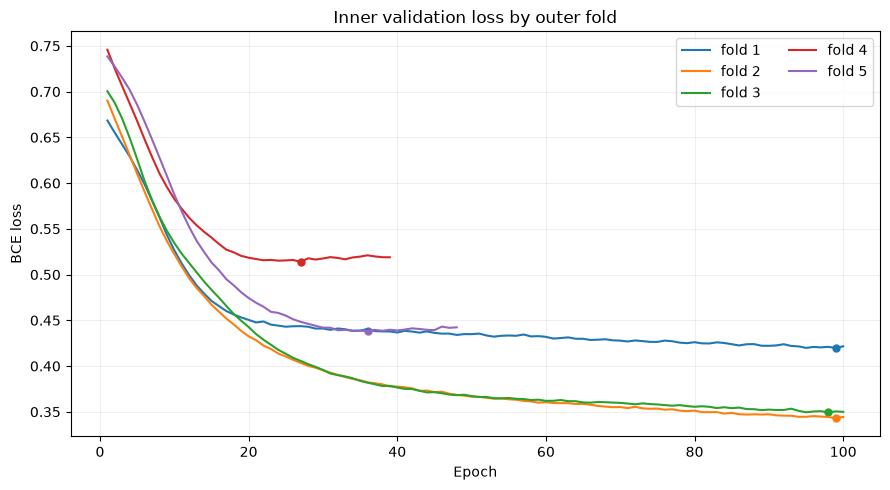

In [5]:
figure = mlp_tools.plot_training_histories(result)
display(figure)
plt.close(figure)


## 5. Reference champion и paired-сравнение

Reference заново обучается на тех же outer folds. Для первого MLP это последний
принятый sklearn-чемпион; для следующих опытов — последний MLP с
`decision: adopt`. Положительный `improvement` всегда означает улучшение,
включая `log_loss`, где меньше — лучше.


In [6]:
if spec.parent_mlp_module:
    reference = mlp_tools.run_mlp_parent_reference(
        raw_train,
        module_name=spec.parent_mlp_module,
        target=project_config.TARGET,
        key=project_config.KEY,
        cv_splits=result.cv_splits,
    )
else:
    reference = mlp_tools.run_sklearn_champion_reference(
        PROJECT_ROOT,
        raw_train,
        module_name=spec.sklearn_reference_module,
        target=project_config.TARGET,
        key=project_config.KEY,
        feature_groups=project_config.FEATURE_GROUPS,
        cv_splits=result.cv_splits,
    )

comparison = mlp_tools.compare_mlp_with_reference(result, reference, spec)
display(comparison.summary.round(4))
display(comparison.criteria.round(4))
display(
    comparison.paired_deltas[
        comparison.paired_deltas["metric"].eq(spec.primary_metric)
    ].round(4)
)


,model,metric,mean,std,min,max
0,MLP-002_reference,accuracy,0.8137,0.0205,0.7865,0.8427
1,MLP-002_reference,balanced_accuracy,0.7929,0.0304,0.7515,0.8343
2,MLP-002_reference,precision,0.7875,0.0088,0.7742,0.7971
3,MLP-002_reference,recall,0.7043,0.0722,0.6029,0.7971
4,MLP-002_reference,f1,0.7420,0.0418,0.6833,0.7971
5,MLP-002_reference,roc_auc,0.8622,0.0196,0.8384,0.8879
6,MLP-002_reference,log_loss,0.4313,0.0234,0.4005,0.4551
7,mlp_candidate,accuracy,0.8114,0.0137,0.7921,0.8258
8,mlp_candidate,balanced_accuracy,0.7895,0.0201,0.7588,0.8126
9,mlp_candidate,precision,0.7884,0.0159,0.7619,0.8033


,role,metric,observed_improvement,minimum_improvement,passed
0,primary,accuracy,-0.0022,0.00,False
1,guardrail,balanced_accuracy,-0.0034,0.00,False
2,guardrail,recall,-0.0086,-0.01,True
3,guardrail,f1,-0.0038,0.00,False


,fold,metric,reference,candidate,improvement
0,1,accuracy,0.8212,0.8212,0.0000
1,2,accuracy,0.8090,0.8146,0.0056
2,3,accuracy,0.7865,0.7921,0.0056
3,4,accuracy,0.8090,0.8034,-0.0056
4,5,accuracy,0.8427,0.8258,-0.0169


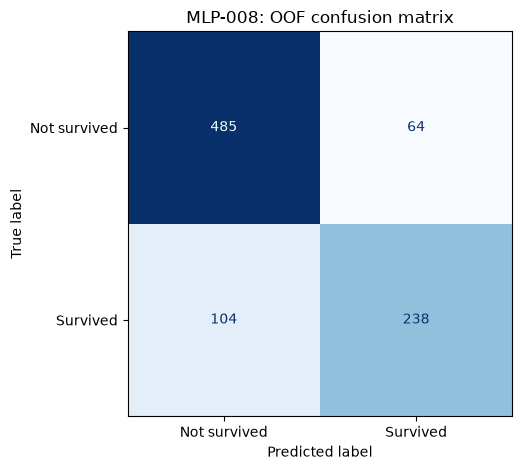

,rows,accuracy,mean_probability
Sex,,,
female,314.0,0.792994,0.732132
male,577.0,0.821490,0.193509


,PassengerId,Sex,Pclass,Name,fold,target,probability,prediction,confidence
297,298,female,1,"Allison, Miss. Helen Loraine",5,0,0.965423,1,0.965423
414,415,male,3,"Sundman, Mr. Johan Julian",2,1,0.036240,0,0.963760
177,178,female,1,"Isham, Miss. Ann Elizabeth",1,0,0.956509,1,0.956509
570,571,male,2,"Harris, Mr. George",3,1,0.045597,0,0.954403
400,401,male,3,"Niskanen, Mr. Juha",2,1,0.046000,0,0.954000
498,499,female,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,0,0.943375,1,0.943375
510,511,male,3,"Daly, Mr. Eugene Patrick",3,1,0.061827,0,0.938173
338,339,male,3,"Dahl, Mr. Karl Edwart",4,1,0.065793,0,0.934207
267,268,male,3,"Persson, Mr. Ernst Ulrik",2,1,0.082500,0,0.917500
579,580,male,3,"Jussila, Mr. Eiriik",4,1,0.085975,0,0.914025


Исправлено ошибок reference: 6
Добавлено новых ошибок: 8


In [7]:
oof = result.oof_predictions
ConfusionMatrixDisplay.from_predictions(
    oof["target"], oof["prediction"], labels=[0, 1],
    display_labels=["Not survived", "Survived"], cmap="Blues", colorbar=False,
)
plt.title(f"{spec.experiment_id}: OOF confusion matrix")
plt.tight_layout()
plt.show()

analysis = raw_train[[project_config.KEY, "Sex", "Pclass", "Name"]].merge(
    oof, on=project_config.KEY, validate="one_to_one"
)
segment_metrics = analysis.groupby("Sex", observed=True).apply(
    lambda part: pd.Series({
        "rows": len(part),
        "accuracy": (part["target"] == part["prediction"]).mean(),
        "mean_probability": part["probability"].mean(),
    }),
    include_groups=False,
)
display(segment_metrics)
display(
    analysis.assign(confidence=lambda x: np.maximum(x.probability, 1-x.probability))
    .query("target != prediction")
    .sort_values("confidence", ascending=False)
    .head(15)
)

candidate_oof = result.oof_predictions.set_index(project_config.KEY)
reference_oof = reference.oof_predictions.set_index(project_config.KEY)
error_changes = candidate_oof[["target", "prediction", "probability"]].join(
    reference_oof[["prediction", "probability"]].rename(columns={
        "prediction": "reference_prediction",
        "probability": "reference_probability",
    }),
    validate="one_to_one",
)
print("Исправлено ошибок reference:", int((
    (error_changes.prediction == error_changes.target)
    & (error_changes.reference_prediction != error_changes.target)
).sum()))
print("Добавлено новых ошибок:", int((
    (error_changes.prediction != error_changes.target)
    & (error_changes.reference_prediction == error_changes.target)
).sum()))


## 6. Вывод до финального fit

- Гипотеза подтвердилась / не подтвердилась: …
- Основная OOF-метрика, paired Δ и fold wins/losses: …
- Что видно по train curves: …
- Ошибки по мужчинам и женщинам: …
- Единственное изменение следующего эксперимента: …

Не подбирайте архитектуру по Kaggle test: там нет target. Новый набор признаков,
imputer, hidden layer, dropout или learning rate оформляйте новым `MLP-xxx`.


## 7. Сохранить результат и Obsidian-карточку

Сохраняются fold metrics, OOF, paired Δ, история эпох и hashes. Затем создаются
карточка `mlp-experiments/MLP-xxx ...md`, CSV-реестр, индекс и блок в README.
Ручной анализ карточки и поле `decision` при перезапуске сохраняются.


In [8]:
run_dir = None
if spec.save_artifacts:
    dataset_path = catalog.path(project_config.TRAIN_DATASET)
    run_dir = mlp_tools.save_mlp_run(
        PROJECT_ROOT, experiment_module, prepared, result,
        target=project_config.TARGET, key=project_config.KEY,
        dataset_path=dataset_path,
        comparison=comparison,
    )
    print("Artifacts:", run_dir.relative_to(PROJECT_ROOT))
    if spec.sync_docs:
        note_path = mlp_tools.sync_mlp_report(
            PROJECT_ROOT,
            experiment_module,
            prepared,
            result,
            comparison,
            run_dir,
            dataset_path=dataset_path,
        )
        print("Obsidian card:", note_path.relative_to(PROJECT_ROOT))
else:
    print("Artifact saving is disabled in EXPERIMENT.")


Artifacts: artifacts\mlp-experiments\MLP-008\5bf4f53d8bc6
Obsidian card: mlp-experiments\MLP-008 Age median by Title.md


## 8. Финальная модель и Kaggle preview

Финальная сеть обучается на всей размеченной таблице; внутри неё остаётся inner
split для выбора эпохи. Это отдельный fit после оценки CV. `SAVE_FINAL_MODEL`
управляет записью весов, preprocessor и CSV. Сначала изучите CV и только затем
включайте сохранение.


In [ ]:
SAVE_FINAL_MODEL = False

if SAVE_FINAL_MODEL:
    if run_dir is None:
        raise RuntimeError("Enable spec.save_artifacts before final model saving")
    final_model = mlp_tools.fit_final_mlp(
        prepared,
        target=project_config.TARGET,
        build_network=experiment_module.build_network,
        spec=spec,
        build_fold_transformer=getattr(experiment_module, "build_fold_transformer", None),
    )
    test_probability = mlp_tools.predict_prepared_mlp(final_model, prepared_test)
    submission = pd.DataFrame({
        project_config.KEY: prepared_test.frame[project_config.KEY].to_numpy(),
        project_config.TARGET: (
            test_probability >= spec.training.threshold
        ).astype("int64"),
    })
    if len(submission) != len(raw_test) or not submission[project_config.KEY].equals(raw_test[project_config.KEY]):
        raise ValueError("Submission row/key contract failed")
    mlp_tools.save_final_mlp(run_dir, final_model)
    submission.to_csv(run_dir / "submission.csv", index=False)
    pd.DataFrame({
        project_config.KEY: prepared_test.frame[project_config.KEY],
        "probability": test_probability,
    }).to_csv(run_dir / "test_probabilities.csv", index=False)
    display(submission.head())
    print("Final model and submission saved to:", run_dir.relative_to(PROJECT_ROOT))
else:
    print("Final fit is disabled. Set SAVE_FINAL_MODEL = True after accepting CV result.")


## 9. Решение и следующий эксперимент

После анализа измените в карточке только `decision:` на `adopt`, `reject`,
`iterate` или `inconclusive`, затем выполните:

```powershell
.\sync-MLPexperiment-state.cmd
```

Из корня проекта:

```powershell
.\new-MLPexperiment.cmd
```

Команда создаст следующий `MLP-xxx`, отдельный модуль и notebook. Старый модуль
после измеренного запуска не редактируйте: он фиксирует точное определение опыта.
